# 📊 Credit Card Default — EDA & Imbalanced Classification Study
**Dataset:** UCI Credit Card Default (Taiwan, 2005)  
**Research Questions:**
1. Imbalance ảnh hưởng thế nào đến ROC-AUC vs PR-AUC?
2. `class_weight='balanced'` có cải thiện Recall@k không?
3. Linear SVC có vượt LogReg ở vùng top-risk không?

> **Môi trường:** Google Colab · Python 3 · Scikit-learn · Seaborn / Matplotlib


In [4]:
# ── Cài đặt & imports ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    classification_report, confusion_matrix
)
from sklearn.calibration import CalibratedClassifierCV

# ── Style toàn cục ──────────────────────────────────────────────────────────
PALETTE = {
    'default': '#E63946',   # đỏ — nợ xấu (class 1)
    'good':    '#457B9D',   # xanh dương — tốt (class 0)
    'lr':      '#2196F3',   # LR
    'lr_bal':  '#FF5722',   # LR balanced
    'svc':     '#4CAF50',   # SVC
    'svc_bal': '#9C27B0',   # SVC balanced
    'bg':      '#0D1117',
    'text':    '#E6EDF3',
}

plt.rcParams.update({
    'figure.facecolor':  PALETTE['bg'],
    'axes.facecolor':    '#161B22',
    'axes.edgecolor':    '#30363D',
    'axes.labelcolor':   PALETTE['text'],
    'xtick.color':       PALETTE['text'],
    'ytick.color':       PALETTE['text'],
    'text.color':        PALETTE['text'],
    'grid.color':        '#21262D',
    'grid.linewidth':    0.6,
    'font.family':       'DejaVu Sans',
    'legend.facecolor':  '#161B22',
    'legend.edgecolor':  '#30363D',
})

print("✅ Setup hoàn tất!")


✅ Setup hoàn tất!


In [5]:
# ── Load dữ liệu ────────────────────────────────────────────────────────────
#upload file UCI_Credit_Card.csv rồi chạy cell này
# from google.colab import files; files.upload()



df = pd.read_csv('UCI_Credit_Card.csv')

# Đổi tên cột target cho gọn
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

TARGET = 'default'
FEATURES = [c for c in df.columns if c not in ['ID', TARGET]]

print(f"Shape: {df.shape}")
print(f"Biến số: {len(FEATURES)} features + 1 target")
print(f"\nTarget distribution:")
vc = df[TARGET].value_counts()
for k, v in vc.items():
    label = 'Nợ xấu' if k==1 else 'Bình thường'
    print(f"  Class {k} ({label}): {v:,}  ({v/len(df)*100:.1f}%)")
df.head(3)


Shape: (30000, 25)
Biến số: 23 features + 1 target

Target distribution:
  Class 0 (Bình thường): 23,364  (77.9%)
  Class 1 (Nợ xấu): 6,636  (22.1%)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0


In [6]:
# ── Mô tả dataset ───────────────────────────────────────────────────────────
print("=" * 65)
print("THÔNG TIN DATASET — UCI Default of Credit Card Clients")
print("=" * 65)
print(f"Số mẫu       : {len(df):,}")
print(f"Số features  : {len(FEATURES)}")
print(f"Missing values: {df.isnull().sum().sum()} (không có missing!)")
print()

schema = {
    'LIMIT_BAL': 'Hạn mức tín dụng (NT$)',
    'SEX':       '1=Nam, 2=Nữ',
    'EDUCATION': '1=Sau ĐH, 2=ĐH, 3=THPT, 4+=Khác',
    'MARRIAGE':  '1=Đã kết hôn, 2=Độc thân, 3=Khác',
    'AGE':       'Tuổi (năm)',
    'PAY_0..6':  'Lịch sử thanh toán T9→T4 (-2=trả trước, 0=đúng hạn, 1-8=trễ N tháng)',
    'BILL_AMT':  'Số dư sao kê T9→T4 (NT$)',
    'PAY_AMT':   'Số tiền thanh toán T9→T4 (NT$)',
    'default':   '1=Vỡ nợ tháng tới, 0=Không vỡ nợ (TARGET)',
}
for col, desc in schema.items():
    print(f"  {col:<12} : {desc}")

print()
print(df[FEATURES].describe().T[['mean','std','min','max']].to_string())


THÔNG TIN DATASET — UCI Default of Credit Card Clients
Số mẫu       : 30,000
Số features  : 23
Missing values: 0 (không có missing!)

  LIMIT_BAL    : Hạn mức tín dụng (NT$)
  SEX          : 1=Nam, 2=Nữ
  EDUCATION    : 1=Sau ĐH, 2=ĐH, 3=THPT, 4+=Khác
  MARRIAGE     : 1=Đã kết hôn, 2=Độc thân, 3=Khác
  AGE          : Tuổi (năm)
  PAY_0..6     : Lịch sử thanh toán T9→T4 (-2=trả trước, 0=đúng hạn, 1-8=trễ N tháng)
  BILL_AMT     : Số dư sao kê T9→T4 (NT$)
  PAY_AMT      : Số tiền thanh toán T9→T4 (NT$)
  default      : 1=Vỡ nợ tháng tới, 0=Không vỡ nợ (TARGET)

                    mean            std       min        max
LIMIT_BAL  167484.322667  129747.661567   10000.0  1000000.0
SEX             1.603733       0.489129       1.0        2.0
EDUCATION       1.853133       0.790349       0.0        6.0
MARRIAGE        1.551867       0.521970       0.0        3.0
AGE            35.485500       9.217904      21.0       79.0
PAY_0          -0.016700       1.123802      -2.0        8.0
PAY_2  

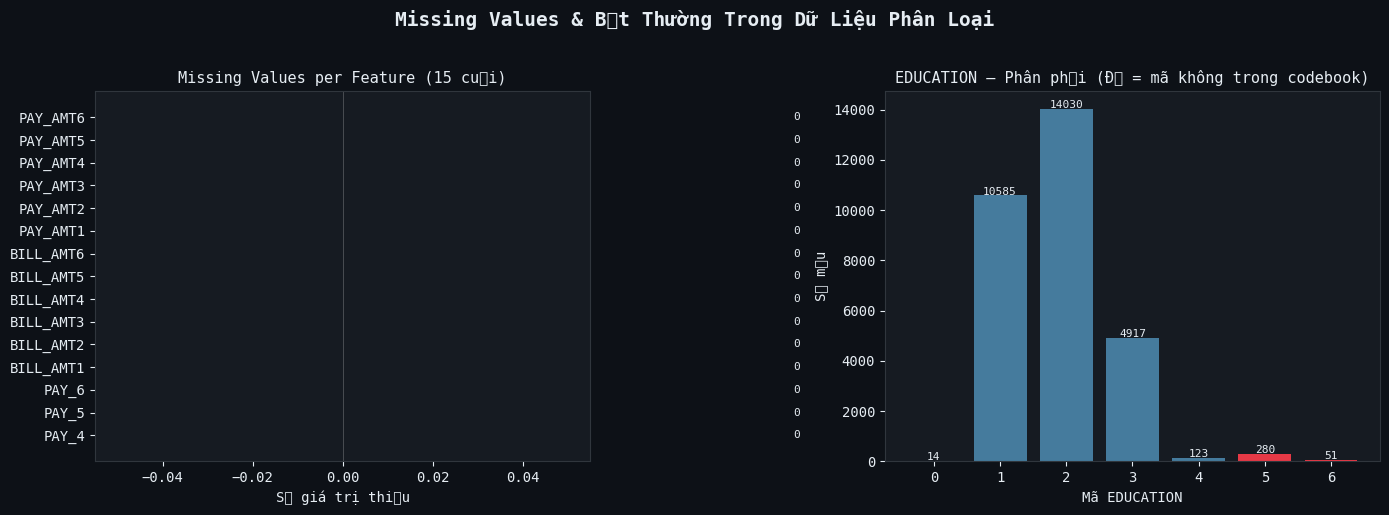


⚠️  Nhận xét:
  • Không có missing values → dataset sạch về mặt hoàn chỉnh
  • EDUCATION có 345 mẫu với mã bất thường (0,5,6)
  • MARRIAGE có 54 mẫu mã 0 không rõ nghĩa
  • Giải pháp: gộp các mã bất thường vào category 'Other'


In [7]:
# ── Missing Values & Anomalies ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Missing Values & Bất Thường Trong Dữ Liệu Phân Loại',
             fontsize=14, fontweight='bold', y=1.02)

# Panel 1: missing heatmap (none here, but show it)
missing = df[FEATURES].isnull().sum()
ax = axes[0]
bars = ax.barh(missing.index[-15:], missing.values[-15:],
               color=[PALETTE['default'] if v>0 else PALETTE['good'] for v in missing.values[-15:]])
ax.set_title('Missing Values per Feature (15 cuối)', fontsize=11)
ax.set_xlabel('Số giá trị thiếu')
ax.axvline(0, color='white', lw=0.5, alpha=0.3)
for bar, val in zip(bars, missing.values[-15:]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=8)

# Panel 2: EDUCATION & MARRIAGE anomaly (code 0, 5, 6 không có trong codebook)
ax2 = axes[1]
edu_counts = df['EDUCATION'].value_counts().sort_index()
edu_labels = {0:'Unknown(0)', 1:'Postgrad(1)', 2:'University(2)', 3:'HS(3)', 4:'Other(4)', 5:'Unknown(5)', 6:'Unknown(6)'}
colors_edu = [PALETTE['default'] if k in [0,5,6] else PALETTE['good'] for k in edu_counts.index]
ax2.bar([str(k) for k in edu_counts.index], edu_counts.values, color=colors_edu, edgecolor='none')
ax2.set_title('EDUCATION — Phân phối (Đỏ = mã không trong codebook)', fontsize=11)
ax2.set_xlabel('Mã EDUCATION')
ax2.set_ylabel('Số mẫu')
for i, v in enumerate(edu_counts.values):
    ax2.text(i, v + 30, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_missing.png', dpi=130, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()

print("\n⚠️  Nhận xét:")
print("  • Không có missing values → dataset sạch về mặt hoàn chỉnh")
print(f"  • EDUCATION có {df['EDUCATION'].isin([0,5,6]).sum()} mẫu với mã bất thường (0,5,6)")
print(f"  • MARRIAGE có {df['MARRIAGE'].isin([0]).sum()} mẫu mã 0 không rõ nghĩa")
print("  • Giải pháp: gộp các mã bất thường vào category 'Other'")
